# Paired colocalization: the SPICE test

All colocalization analyses so far have compared one brain map against a set of reference maps — testing which references are associated with the observed spatial pattern. But sometimes we have **matched pairs**: the same brain map measured by two different methods, two modalities, or two processing pipelines.

The natural question for paired data is: does the brain map agree more strongly *within a pair* (same unit, different measurement) than *across pairs* (different units)? This within-pair vs. between-pair structure is exactly what the **SPICE test** (Weinstein et al. 2021) captures.

NiSpace implements the SPICE test in `paired_colocalization()` (and the underlying `permute(what="pairs")` method).

In [2]:
import tqdm.notebook
tqdm.notebook.tqdm = tqdm.tqdm

import numpy as np
import pandas as pd
from nispace.datasets import fetch_reference, fetch_collection
from nispace.workflows import paired_colocalization

## The idea: within-pair vs. between-pair correspondence

Suppose we have N units (genes, subjects, studies, tracers), each measured by two different methods, yielding two brain maps per unit:

- **Method A** (e.g., standard AHBA processing): N maps $a_1, \ldots, a_N$
- **Method B** (e.g., MAGICC denoising): N maps $b_1, \ldots, b_N$

Computing all pairwise correlations gives an N×N matrix. The **diagonal** holds within-pair correlations ($a_i$ vs. $b_i$ — the same unit). The **off-diagonal** holds between-pair correlations ($a_i$ vs. $b_j$, $i \neq j$). The SPICE test asks: is the mean diagonal correlation significantly higher than we'd expect by chance under a null where pair labels are permuted?

### Why this null is cheap

Once the N×N matrix is computed, each permutation is just a row-index shuffle — no re-colocalization needed. This makes the null essentially free regardless of N.

## Example: mRNA vs. MAGICC processing of AHBA gene expression

The Allen Human Brain Atlas (AHBA) provides spatial gene expression profiles across the human cortex. These data were reconstructed to neuroimaging spaces by different groups. Two of the resulting datasets we ship as references in NiSpace.

- **`mrna`**: AHBA samples matched to parcels of a given parcellation
- **`magicc`**: full cortical surface interpolation of AHBA samples 

The same gene should produce more similar cortical maps across the two pipelines than different genes. The SPICE test lets us quantify this formally.

We use the **PsychENCODE cell type marker genes** as our gene sets (`CellTypesPsychEncodeTPM`). There are 24 cell types; we select one for the demo.

In [3]:
# Inspect the collection: 24 cell types, each with a set of marker genes
collection = fetch_collection("CellTypesPsychEncodeTPM", "mrna")
print(f"Total genes in collection: {len(collection)}")
print(f"\nCell types ({collection['set'].nunique()} total):")
for ct, n in collection.groupby('set')['map'].count().items():
    print(f"  {ct}: {n} genes")

INFO | 16/07/26 23:17:09 | nispace.datasets: Loading integrated collection 'CellTypesPsychEncodeTPM' for dataset 'mrna'.


INFO | 16/07/26 23:17:09 | nispace.datasets: Filtering maps by collection.


Total genes in collection: 592

Cell types (24 total):
  Astrocyte: 40 genes
  Developing-quiescent: 17 genes
  Developing-replicating: 40 genes
  Endothelial: 83 genes
  Ex1 CortProject (L2/3): 18 genes
  Ex2 Granule (L3/4): 11 genes
  Ex3 Granule (L4): 9 genes
  Ex4 SubcortProject (L4): 17 genes
  Ex5 SubcortProject (L4-6): 15 genes
  Ex6 SubcortProject (L5-6): 38 genes
  Ex7 Corticothalamic: 6 genes
  Ex8 Corticothalamic (L6): 65 genes
  In1 VIP+RELN+NDNF+ (L1/2): 2 genes
  In2 VIP+RELN-NDNF- (L6): 7 genes
  In3 VIP+RELN+NDNF- (L6): 20 genes
  In4 VIP-RELN+NDNF+ (L1-3): 11 genes
  In5 CCK+NOS1+CALB2+ (L2/3): 11 genes
  In6 PVALB+CRHBP+ (L4/5): 6 genes
  In7 SST+CALB1+NPY+ (L5/6): 13 genes
  In8 SST+NOS1+ (L6): 4 genes
  Microglia: 25 genes
  OPC: 53 genes
  Oligodendrocyte: 35 genes
  Other Neurons: 46 genes


In [4]:
# Fetch gene expression maps for both pipelines, filtered to collection genes
# (465 genes × 200 cortical parcels for each)
mrna_all = fetch_reference(
    "mrna", parcellation="Yan200",
    collection="CellTypesPsychEncodeTPM", print_references=False
)
magicc_all = fetch_reference(
    "magicc", parcellation="Yan200",
    collection="CellTypesPsychEncodeTPM", print_references=False
)
print(f"mrna shape:   {mrna_all.shape}  (genes × parcels)")
print(f"magicc shape: {magicc_all.shape}")

# Select one cell type
# 'Astrocyte' markers have a simple, interpretable biology —
# but any of the 24 cell types works the same way
cell_type = "Astrocyte"

mrna_ct   = mrna_all.xs(cell_type,   level="set")  # (N_genes, 200)
magicc_ct = magicc_all.xs(cell_type, level="set")  # (N_genes, 200)

# Align to common genes (in case the two datasets differ slightly)
common_genes = mrna_ct.index.intersection(magicc_ct.index)
mrna_ct   = mrna_ct.loc[common_genes]
magicc_ct = magicc_ct.loc[common_genes]

print(f"\n{cell_type}: {len(common_genes)} paired genes")
print(f"First 5 genes: {list(common_genes[:5])}")

INFO | 16/07/26 23:17:09 | nispace.datasets: Loading mrna maps.


INFO | 16/07/26 23:17:09 | nispace.datasets: Loading integrated collection 'CellTypesPsychEncodeTPM' for dataset 'mrna'.


INFO | 16/07/26 23:17:09 | nispace.datasets: Filtering maps by collection.


INFO | 16/07/26 23:17:10 | nispace.datasets: Loading data parcellated with 'Yan200'


INFO | 16/07/26 23:17:10 | nispace.datasets: Loading magicc maps.


INFO | 16/07/26 23:17:10 | nispace.datasets: Loading integrated collection 'CellTypesPsychEncodeTPM' for dataset 'magicc'.


INFO | 16/07/26 23:17:10 | nispace.datasets: Filtering maps by collection.


INFO | 16/07/26 23:17:10 | nispace.datasets: Loading data parcellated with 'Yan200'


mrna shape:   (465, 200)  (genes × parcels)
magicc shape: (445, 200)

Astrocyte: 26 paired genes
First 5 genes: ['ACSBG1', 'ALDH1L1', 'BMPR1B', 'CLTCL1', 'COL16A1']


## Running the SPICE test

`paired_colocalization()` expects:
- `y`: the first modality (here: mrna gene maps) — N rows, one per pair
- `x`: the second modality (here: magicc gene maps) — same N rows, same order

Pairing is **positional**: row $i$ in `y` is paired with row $i$ in `x`. Both DataFrames have identical gene-name indices here, so alignment is exact.

In [5]:
nsp = paired_colocalization(
    y=mrna_ct,
    x=magicc_ct,
    parcellation="Yan200",
    colocalization_method="spearman",
    n_perm=10000,
    seed=42,
    n_proc=-1,
    plot=False
)

INFO | 16/07/26 23:17:10 | nispace.api: *** NiSpace.fit() - Data extraction and preparation. ***


INFO | 16/07/26 23:17:10 | nispace.core.parcellation: Building cortex Parcellation for 'Yan200' from library. DOI: 10.1016/j.neuroimage.2023.120010


INFO | 16/07/26 23:17:10 | nispace.core.parcellation: Available spaces: MNI152NLin2009cAsym, MNI152NLin6Asym, fsLR, fsaverage


INFO | 16/07/26 23:17:11 | nispace.core.parcellation: Parcellation 'Yan200': validation passed.


INFO | 16/07/26 23:17:11 | nispace.api: Checking input data for 'x' (should be, e.g., PET data):


...

INFO | 16/07/26 23:17:16 | nispace.api: *** NiSpace.permute() - Estimate exact non-parametric p values. ***


INFO | 16/07/26 23:17:16 | nispace.api: Permutation of: Y–X matched pairs (SPICE).


INFO | 16/07/26 23:17:16 | nispace.api: Using default null method 'moran' (parcellation null space: 'fsLR').


INFO | 16/07/26 23:17:16 | nispace.core.parcellation: Lazy-loading parcellation image for space 'fsLR'.


INFO | 16/07/26 23:17:16 | nispace.api: Loading observed colocalizations (method = 'spearman').


## Results: the N×N matrix and within-pair p-value

In [6]:
# Full pairwise colocalization matrix (N × N)
coloc_mat = nsp.get_colocalizations()
print(f"Colocalization matrix: {coloc_mat.shape}")
print(f"  Mean diagonal (within-pair):      {np.diag(coloc_mat.values).mean():.3f}")
print(f"  Mean off-diagonal (between-pair): {coloc_mat.values[~np.eye(len(coloc_mat), dtype=bool)].mean():.3f}")

# p-value for within > between
p = nsp.get_p_values()
print(f"\nSPICE p-value (within > between): {p.values.squeeze():.4f}")

Colocalization matrix: (26, 26)
  Mean diagonal (within-pair):      0.835
  Mean off-diagonal (between-pair): 0.313

SPICE p-value (within > between): 0.0001


INFO | 16/07/26 23:17:17 | nispace.plotting: Significance annotation: 1/1 p_uncorrected < 0.05, 0/1 p_corrected < 0.05 (no correction applied)


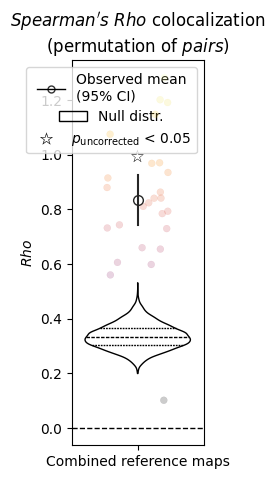

(<Figure size 170x500 with 1 Axes>,
 <Axes: title={'center': "$Spearman's\\ Rho$ colocalization\n(permutation of $pairs$)"}, ylabel='$Rho$'>,
 <seaborn._core.plot.Plotter at 0x162fe6c40>)

In [7]:
# Plot: diagonal values against the null distribution
# The scatter shows each gene's within-pair correlation;
# the violin shows the null distribution of the mean diagonal under permutation.
# (These plots are partly experimental and will be improved in the future.)
nsp.plot(permute_what="pairs")

## Interpretation

Each point in the scatter represents one gene: its within-pair correlation between the mrna and MAGICC versions of that gene's spatial expression map across 200 cortical parcels. The violin shows the null distribution — the expected mean diagonal if pair labels were randomly shuffled.

A significant p-value means that the observed within-pair agreement is higher than chance. For gene expression data, this confirms that the two processing pipelines produce consistent spatial maps for the same gene — not a trivial result, since the two methods apply very different normalization strategies.

### Generalizability

"Pairs" can be any matched units:
- **Subjects**: structure vs. function per person (does each person's structural map predict their own functional map better than anyone else's?)
- **Studies**: each study contributes one map per modality
- **Tracers**: within-target vs. across-target receptor correspondence

The only requirement is that the two modalities have matching rows (same N, same order).

## Summary

- `paired_colocalization(y=modality_A, x=modality_B)` runs the SPICE test: within-pair vs. between-pair correspondence.
- The N×N pairwise colocalization matrix is computed once; the null is built by permuting pair labels (essentially free).
- `get_p_values()` returns a single p-value (`index=["within_pair"]`).
- `get_colocalizations()` returns the full N×N matrix.
- `plot(permute_what="pairs")` shows the diagonal against the null violin.

**Reference:** Weinstein, J. D., et al. (2021). A simple permutation-based test of intermodal correspondence. *Human Brain Mapping*, 42(18), 5957–5972. https://doi.org/10.1002/hbm.25577